# 设计模式

* 工作流：LLM 和相关工具通过显式预定义的代码路径进行编排的系统
* agent：大语言模型（LLM）动态指导自身流程的系统，实时决策工具的使用以及实现目标所需的步骤

这俩的区别就是，一个是预先定义的流程，一个是动态的流程；

## 提示链
> 提示链是一种基本的工作流模式，专注于将复杂任务分解为一系列更简单、相互关联的步骤。在这种工作流中，一个 LLM 调用的输出成为后续调用的输入，从而创建一系列处理阶段。


In [3]:
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
import os
from dotenv import load_dotenv

load_dotenv()



True

In [4]:
# 使用 TypedDict 定义图状态，用于类型提示和状态管理
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

# 配置模型
llm = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
)

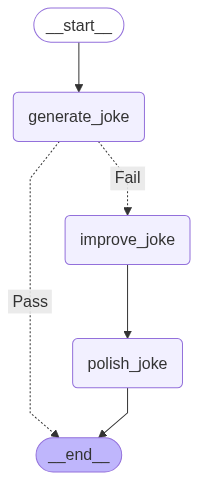

In [15]:
# 图中的节点，每个节点代表提示链中的一个步骤
def generate_joke(state: State):
    """第一个 LLM 调用，根据主题生成初始笑话"""
    msg = llm.invoke(f"写一个关于 {state['topic']} 的简短笑话") # 使用状态中的主题调用 LLM
    return {"joke": msg.content} # 返回生成的笑话，更新状态中的 'joke' 键

def check_punchline(state: State):
    """门控函数，检查笑话是否有妙语"""
    # 简单检查 - 笑话是否包含 "?" 或 "!" 作为妙语存在的代理
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"   # 有妙语
    return "Fail"       # 没妙语，需要改进

def improve_joke(state: State):
    """第二个 LLM 调用，通过添加文字游戏来改进笑话"""
    msg = llm.invoke(f"通过添加文字游戏使这个笑话更有趣：{state['joke']}") # 调用 LLM 来改进笑话
    return {"improved_joke": msg.content} # 返回改进后的笑话，更新状态中的 'improved_joke'

def polish_joke(state: State):
    """第三个 LLM 调用，用于最终润色，添加令人惊讶的转折"""
    msg = llm.invoke(f"为这个笑话添加一个令人惊讶的转折：{state['improved_joke']}") # 调用 LLM 来润色笑话
    return {"final_joke": msg.content} # 返回润色后的笑话，更新状态中的 'final_joke'

# 使用 StateGraph 构建工作流，使用定义的状态进行初始化
workflow = StateGraph(State)

# 将节点添加到工作流图中，将它们与定义的函数关联起来
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# 定义边缘以连接节点并建立工作流序列
workflow.add_edge(START, "generate_joke") # 开始节点连接到 'generate_joke' 节点
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END} # 'generate_joke' 之后的条件边缘，基于 'check_punchline' 输出
)
workflow.add_edge("improve_joke", "polish_joke") # 'improve_joke' 节点连接到 'polish_joke' 节点
workflow.add_edge("polish_joke", END) # 'polish_joke' 节点连接到结束节点

# 将工作流图编译为可执行链
chain = workflow.compile()

from IPython.display import Image, display
try:
    display(Image(chain.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [17]:
# 使用初始状态（主题："cats"）调用编译链
state = {
    "topic": "猫咪",
}

state = chain.invoke(state)
print("初始笑话：")
print(state["joke"])
print("="*80)

if "improved_joke" in state and state["improved_joke"]: # 检查 'improved_joke' 是否存在于状态中，指示妙语检查失败
    print("\n改进后的笑话：")
    print(state["improved_joke"])
    print("="*80)
    print("\n最终笑话：")
    print(state["final_joke"])
else:
    print("不需要改进")

初始笑话：
有一天，一只猫咪跳上键盘，主人一看，电脑屏幕上只有一串字母：  
**“Meeeeeeeeowwwwwwwwwwwww”**  

主人笑着说：“你这是在写自传吗？”

改进后的笑话：
当然可以！下面是一个加入文字游戏、让笑话更有趣的版本：

---

有一天，一只猫咪跳上键盘，主人一看，电脑屏幕上只有一串字母：  
**“Meeeeeeeeowwwwwwwwwwwww”**

主人笑着说：“你这是在写自传吗？这开头也太‘喵’长了吧！”

猫咪头也不抬地继续踩键盘：“别急，这还是**未完待续（喵）**呢！”

---

是不是更有意思了？如果你想让它更押韵、更有梗，或者变成诗歌版、成语版，也可以告诉我，我来帮你改写！

最终笑话：
当然可以！下面是在你这个版本基础上，加入一个**令人意想不到的转折结局**，让整个笑话在幽默之余多了一丝“细思极恐”的感觉：

---

有一天，一只猫咪跳上键盘，主人一看，电脑屏幕上只有一串字母：  
**“Meeeeeeeeowwwwwwwwwwwww”**

主人笑着说：“你这是在写自传吗？这开头也太‘喵’长了吧！”

猫咪头也不抬地继续踩键盘：“别急，这还是**未完待续（喵）**呢！”

主人正要关掉文档，突然发现——  
**光标开始自动移动，键盘自己在敲字……**

“我早就写完了，”一个低沉的声音从电脑喇叭传出，  
“现在是我在**续写你的人生**。”

---

怎么样？是不是从轻松搞笑一下子变成了“喵生惊悚剧场”？如果你喜欢这种风格，我还能给你整出一个“猫咪恐怖短篇系列”！😄  
当然，如果你想要温馨、浪漫、搞笑甚至科幻的转折，也可以告诉我，我来按你喜欢风格定制！


## 路由

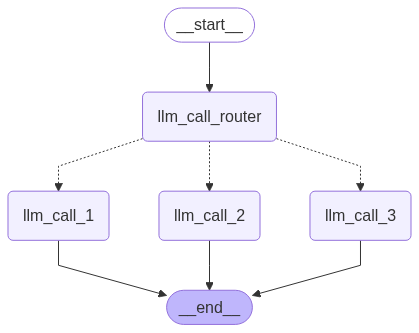

In [22]:
import json
from langchain_core.messages import HumanMessage, SystemMessage

# 路由工作流的状态定义
class State(TypedDict):
    input: str
    decision: str
    output: str

# 图中的节点，每个节点处理特定的路由 (story, joke, poem)
def llm_call_1(state: State):
    """写一个故事"""
    result = llm.invoke(state["input"]) # 调用 LLM 根据输入写一个故事
    return {"output": result.content} # 返回故事，更新状态中的 'output'

def llm_call_2(state: State):
    """写一个笑话"""
    result = llm.invoke(state["input"]) # 调用 LLM 根据输入写一个笑话
    return {"output": result.content} # 返回笑话，更新状态中的 'output'

def llm_call_3(state: State):
    """写一首诗"""
    result = llm.invoke(state["input"]) # 调用 LLM 根据输入写一首诗
    return {"output": result.content} # 返回诗歌，更新状态中的 'output'

def llm_call_router(state: State):
    """使用结构化输出将输入路由到适当的节点"""
    # 使用结构化输出调用增强型 LLM，以充当路由逻辑
    model = ChatOpenAI(
        model=os.getenv("MODEL_NAME"),
        base_url=os.getenv("BASE_URL"),
        api_key=os.getenv("OPENAI_API_KEY"),
        temperature=0,
        model_kwargs={"response_format": {"type": "json_object"}},
    )
    ai_msg = model.invoke(
        [
            SystemMessage(
                content="You are a router that directs user input to the appropriate handler. Return a JSON object with a 'step' key and one of these values: 'story', 'joke', or 'poem'. For example: {'step': 'joke'}" # 路由 LLM 的系统消息
            ),
            HumanMessage(content=state["input"]), # 用户输入消息
        ]
    )
    decision = json.loads(ai_msg.content)
    return {"decision": decision["step"]} # 返回路由决策，更新状态中的 'decision'

# 条件边缘函数，根据决策路由到适当的节点
def route_decision(state: State):
    # 根据状态中的 'decision' 返回您想要访问的下一个节点名称
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

# 使用 StateGraph 构建路由工作流
router_builder = StateGraph(State)

# 将节点添加到图中
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# 定义边缘以连接节点并建立路由逻辑
router_builder.add_edge(START, "llm_call_router") # 开始节点连接到路由器节点
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # 由 route_decision 返回的名称：要访问的下一个节点的名称
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
) # 从路由器到专用节点的条件边缘，基于路由决策
router_builder.add_edge("llm_call_1", END) # 专用节点连接到结束节点
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# 编译路由工作流图
router_workflow = router_builder.compile()

from IPython.display import Image, display
try:
    display(Image(router_workflow.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [23]:
# 使用示例输入调用路由工作流
state = router_workflow.invoke({"input": "给我写一个关于猫的笑话"})
print(state["output"]) 

当然可以！来一个轻松可爱的猫笑话：

有一天，一只猫走进了图书馆，走到前台对图书管理员说：

“喵~ 有没有鱼的书？”

图书管理员一愣，给了它一本关于鱼的书。

第二天，猫又来了，说：

“喵~ 有没有鱼的书？”

图书管理员又给了它同一本书。

第三天，猫又来了，说：

“喵~ 有没有鱼的书？”

这次图书管理员有点不耐烦了，干脆把书直接扔给它。

猫看着书，一脸无奈地说：

“喵？！我是想借书……不是来钓鱼的啊！！”

😄  
希望这个笑话能让你笑一笑！要不要再来一个不同风格的？


## 并行化

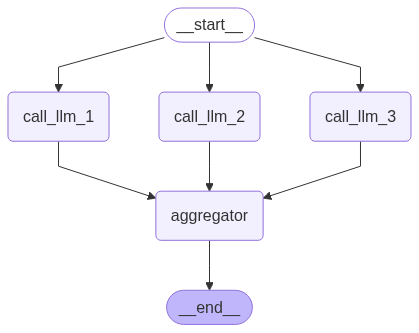

In [24]:
# 并行工作流的图状态定义
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

llm = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
)

# 图中的节点，每个节点并行生成不同类型的内容
def call_llm_1(state: State):
    """第一个 LLM 调用，生成初始笑话"""
    msg = llm.invoke(f"写一个关于 {state['topic']} 的笑话") # 调用 LLM 以根据主题写一个笑话
    return {"joke": msg.content} # 返回笑话，更新状态中的 'joke'

def call_llm_2(state: State):
    """第二个 LLM 调用，生成故事"""
    msg = llm.invoke(f"写一个关于 {state['topic']} 的故事") # 调用 LLM 以根据主题写一个故事
    return {"story": msg.content} # 返回故事，更新状态中的 'story'

def call_llm_3(state: State):
    """第三个 LLM 调用，生成诗歌"""
    msg = llm.invoke(f"写一首关于 {state['topic']} 的诗歌") # 调用 LLM 以根据主题写一首诗
    return {"poem": msg.content} # 返回诗歌，更新状态中的 'poem'

def aggregator(state: State):
    """将笑话、故事和诗歌组合成单个输出"""
    combined = f"这是一个关于 {state['topic']} 的故事、笑话和诗歌！\n\n" # 开始组合输出
    combined += f"故事：\n{state['story']}\n\n" # 将故事添加到组合输出
    combined += f"笑话：\n{state['joke']}\n\n" # 将笑话添加到组合输出
    combined += f"诗歌：\n{state['poem']}" # 将诗歌添加到组合输出
    return {"combined_output": combined} # 返回组合输出，更新状态中的 'combined_output'

# 使用 StateGraph 构建并行工作流
parallel_builder = StateGraph(State)

# 将节点添加到图中
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# 定义边缘以连接节点并建立并行执行
parallel_builder.add_edge(START, "call_llm_1") # 开始节点连接到 'call_llm_1' 以进行并行执行
parallel_builder.add_edge(START, "call_llm_2") # 开始节点连接到 'call_llm_2' 以进行并行执行
parallel_builder.add_edge(START, "call_llm_3") # 开始节点连接到 'call_llm_3' 以进行并行执行
parallel_builder.add_edge("call_llm_1", "aggregator") # 'call_llm_1' 节点在完成后连接到聚合器
parallel_builder.add_edge("call_llm_2", "aggregator") # 'call_llm_2' 节点在完成后连接到聚合器
parallel_builder.add_edge("call_llm_3", "aggregator") # 'call_llm_3' 节点在完成后连接到聚合器
parallel_builder.add_edge("aggregator", END) # 聚合器节点连接到结束节点

# 编译并行工作流图
parallel_workflow = parallel_builder.compile()

from IPython.display import Image, display
try:
    display(Image(parallel_workflow.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [25]:
# 使用示例输入调用并行工作流
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"]) 

这是一个关于 cats 的故事、笑话和诗歌！

故事：
标题：**《月光下的猫之城》**

在遥远的山谷深处，隐藏着一座人类从未发现的城市——**喵洛尼亚**。这里没有人类的喧嚣，只有猫咪们的低语与夜风的轻吟。每到月圆之夜，整座城市都会被银白色的光芒笼罩，而这时，也是喵洛尼亚最神秘的时刻。

故事的主角是一只名叫**影爪**的黑猫。它有着如夜色般深邃的毛发，以及一双仿佛能看穿人心的翡翠色眼睛。影爪是喵洛尼亚的“夜巡者”，负责在夜晚守护城市的安宁。

喵洛尼亚原本和平而宁静，直到有一天，一只受伤的信天翁坠落在城市的钟楼顶上。它的翅膀上绑着一封古老的卷轴，上面写着一句话：

> “当星辰坠落于猫眼之湖，古老的契约将被唤醒。”

影爪展开调查，发现这封卷轴来自一个早已被遗忘的传说——传说中，喵洛尼亚的建立，是因为猫族与一位星辰之灵签订了契约，以换取自由与智慧。而如今，契约似乎正在被某种力量打破。

影爪踏上旅程，穿越猫眼之湖，进入被遗忘的“影之森林”，在那里，它遇见了传说中的**白猫先知**——一只据说活了百年的猫灵。白猫告诉影爪，契约的破裂是因为人类世界的贪婪与冷漠正在侵蚀喵洛尼亚的边界。

“只有真正的‘心之语者’，才能重新唤醒契约。”白猫低声说道。

影爪回到喵洛尼亚后，召集了城中最聪明的猫——**图书猫**、**机械猫**、**梦境猫**和**火焰猫**，他们一起研究卷轴的秘密。最终，他们发现，所谓“心之语者”，其实是一只从未被训练、从未被驯服的野猫，它的心灵纯净无瑕，能听见星辰的语言。

在一次月圆之夜，他们找到了那只野猫——一只名叫**风尾**的小橘猫，它来自城市边缘的荒野，从不信任人类，也从未被人类触碰。

风尾被带到了猫眼之湖，湖面开始泛起星光般的涟漪。当它低头凝视湖水时，湖中浮现出一只巨大的猫形星辰，它低声低语，声音如同风穿过山谷。

契约被重新唤醒，喵洛尼亚再次被星光笼罩，城市恢复了原有的宁静与魔法。

而影爪，在那之后，成了喵洛尼亚的第一位“契约守护者”，带领着猫族继续守护这片神秘的土地。

至于风尾？它选择了自由，继续在荒野奔跑，偶尔在月圆之夜，会出现在喵洛尼亚的城墙上，望着那片属于猫族的星空。

---

**结尾语：**

每一只猫，都是星辰的守护者。  
在你看不见的角落，它们正守护着属于自己的秘密王国。

笑话：
当然！这里有一个关于猫的笑

## 协调器-工作者 workflow 工作流

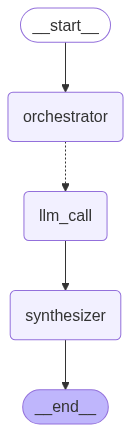

In [31]:
import operator
from typing import Annotated, List, TypedDict
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


# 用于结构化输出的模式，用于规划报告章节
class Section(BaseModel):
    name: str = Field(
        description="报告章节的名称", # 报告章节的名称
    )
    description: str = Field(
        description="本章节中要涵盖的主要主题和概念的简要概述", # 章节内容的描述
    )

class Sections(BaseModel):
    sections: List[Section] = Field(
        description="报告的章节", # 报告章节列表
    )

# 用于规划报告章节的增强型 LLM，使用结构化输出
llm = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
)
planner = llm.with_structured_output(Sections, method="function_calling")

# 协调器-工作者工作流的图状态定义
class State(TypedDict):
    topic: str  # 报告主题
    sections: list[Section]  # 由协调器规划的报告章节列表
    completed_sections: Annotated[
        list, operator.add
    ]  # 所有工作者并行写入此键，使用 operator.add 进行列表连接
    final_report: str  # 最终合成报告


# 工作者状态定义，特定于工作者节点
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add] # 工作者也写入共享的 'completed_sections' 键

# 图中的节点
def orchestrator(state: State):
    """协调器，使用结构化输出生成报告计划"""
    # 使用 planner LLM 和结构化输出生成报告章节计划
    report_sections = planner.invoke(
        [
            SystemMessage(content="生成报告计划。"), # planner LLM 的系统消息
            HumanMessage(content=f"这是报告主题：{state['topic']}"), # 包含报告主题的用户输入消息
        ]
    )
    return {"sections": report_sections.sections} # 返回计划的章节，更新状态中的 'sections'

def llm_call(state: WorkerState):
    """工作者根据分配的章节详细信息编写报告章节"""
    # 使用 LLM 根据章节名称和描述生成报告章节内容
    section = llm.invoke(
        [
            SystemMessage(
                content="按照提供的名称和描述编写报告章节。每节不包含序言。使用 markdown 格式。" # 工作者 LLM 的系统消息
            ),
            HumanMessage(
                content=f"这是章节名称：{state['section'].name} 和描述：{state['section'].description}" # 包含章节详细信息的用户消息
            ),
        ]
    )
    # 将生成的章节内容写入共享的 'completed_sections' 键
    return {"completed_sections": [section.content]}

def synthesizer(state: State):
    """从各个章节输出合成完整报告"""
    # 从共享状态检索已完成章节的列表
    completed_sections = state["completed_sections"]

    # 将已完成章节格式化为单个字符串以用于最终报告
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections} # 返回最终报告，更新状态中的 'final_report'

# 条件边缘函数，用于将工作者动态分配给计划中的每个章节
def assign_workers(state: State):
    """使用 Send API 将工作者分配给计划中的每个章节，以实现动态工作者创建"""
    # 使用 Send API 为每个章节动态创建和发送 'llm_call' 工作者节点
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

# 使用 StateGraph 构建协调器-工作者工作流
orchestrator_worker_builder = StateGraph(State)

# 将节点添加到图中
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call) # 工作者节点
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# 定义边缘以连接节点并建立协调器-工作者流程
orchestrator_worker_builder.add_edge(START, "orchestrator") # 开始节点连接到协调器
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"] # 从协调器到使用 Send API 动态创建的工作者节点的条件边缘
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer") # 工作者节点在完成后连接到合成器
orchestrator_worker_builder.add_edge("synthesizer", END) # 合成器节点连接到结束节点

# 编译协调器-工作者工作流图
orchestrator_worker = orchestrator_worker_builder.compile()

from IPython.display import Image, display
try:
    display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [28]:
# 使用示例报告主题调用协调器-工作者工作流
state = orchestrator_worker.invoke({"topic": "创建关于 LLM 缩放定律的报告"})

from IPython.display import Markdown
Markdown(state["final_report"]) # 以 Markdown 格式显示最终报告

## 引言

近年来，大型语言模型（Large Language Models, LLMs）在自然语言处理领域取得了显著进展。这些模型通过在大规模语料库上进行训练，能够生成高质量的文本、回答复杂问题，并在多种任务中展现出接近甚至超越人类的表现。随着模型规模的不断扩展，研究者发现模型性能与模型大小、训练数据量和计算资源之间存在某种规律性关系，这种关系被称为“缩放定律”（Scaling Laws）。

LLM缩放定律的研究不仅揭示了模型性能随规模变化的趋势，还为模型设计、资源分配和未来发展方向提供了理论依据。理解这些定律对于优化模型训练效率、降低成本、提升性能具有重要意义。本文将围绕LLM缩放定律展开探讨，分析其背后机制、实证结果及其对人工智能发展的深远影响。

---

## 理论基础

### LLM 缩放定律的数学原理

大语言模型（LLM）的缩放定律（Scaling Laws）描述了模型性能如何随模型大小、训练数据量和计算资源的变化而变化。这些定律通常基于经验观察，但可以通过数学建模和统计学习理论提供一定的理论解释。

#### 1. 基本形式

LLM 缩放定律的核心思想是模型的损失函数（Loss）可以表示为模型参数数量 $ N $、训练数据量 $ D $ 和计算资源 $ C $ 的函数。最常见的一种形式为：

$$
L(N, D, C) \approx a N^{-\alpha} + b D^{-\beta} + c C^{-\gamma}
$$

其中：
- $ L $ 是模型的验证损失；
- $ a, b, c $ 是常数系数；
- $ \alpha, \beta, \gamma $ 是经验拟合的指数，通常在 0.1 到 0.5 之间。

该公式表明，随着模型参数数量、数据量或计算资源的增加，损失函数会以幂律形式递减。

#### 2. 模型规模与性能的关系

在固定训练数据量和计算资源的条件下，模型性能与参数数量之间的关系通常遵循幂律：

$$
L(N) \propto N^{-\alpha}
$$

这说明，模型越大，性能越好，但收益递减。指数 $ \alpha $ 反映了模型扩展的效率：如果 $ \alpha $ 接近于 1，则增加参数数量对性能提升的效果显著；而如果 $ \alpha $ 接近于 0，则性能提升趋于饱和。

#### 3. 数据量与性能的关系

类似地，在固定模型大小和计算资源的条件下，训练数据量与损失函数之间的关系为：

$$
L(D) \propto D^{-\beta}
$$

这说明，增加训练数据可以提升模型泛化能力，但同样存在边际效益递减的现象。

#### 4. 计算资源的限制

训练所使用的计算资源（如GPU小时数）也影响模型性能。在固定模型大小和数据量的情况下，损失函数随计算资源的增加而下降：

$$
L(C) \propto C^{-\gamma}
$$

这反映了训练时间或优化过程对模型最终性能的影响。

#### 5. 联合缩放与最优分配

当同时调整模型大小、数据量和计算资源时，可以通过联合优化来找到最优的资源分配策略。例如，在固定总成本 $ T = N + D + C $ 的约束下，寻找使损失最小的 $ N, D, C $ 组合。

一种常见的做法是使用拉格朗日乘子法进行优化：

$$
\min_{N, D, C} L(N, D, C) \quad \text{subject to} \quad N + D + C = T
$$

通过求解相应的拉格朗日方程，可以得到在给定预算下最优的模型参数分配策略。

#### 6. 实验验证与局限性

虽然缩放定律在经验上表现良好，但它们通常基于特定任务和模型架构（如Transformer）的训练结果。因此，这些定律在跨任务或跨架构应用时可能不完全适用。此外，缩放定律未考虑训练策略、优化器设置、数据质量等因素，这些都可能显著影响模型性能。

综上所述，LLM 缩放定律提供了一个量化模型性能与资源投入之间关系的数学框架，有助于指导模型设计和资源分配策略。

---

## 应用实例

### 自然语言处理中的模型优化

在自然语言处理（NLP）领域，LLM缩放定律被广泛用于指导模型架构与训练资源的优化。例如，OpenAI 在开发 GPT-3 和后续模型时利用缩放定律预测不同参数量级下的模型性能。通过在较小规模模型上进行实验并应用缩放定律，研究人员能够估算出在更大参数量和数据集规模下模型的表现，从而在计算资源有限的情况下做出更优的模型设计决策。

### 个性化推荐系统的改进

在推荐系统中，LLM缩放定律帮助工程师评估模型复杂度与推荐准确率之间的关系。例如，一些大型电商平台在构建基于语言模型的个性化推荐系统时，使用缩放定律预测在增加模型参数数量或训练数据量后推荐效果的提升幅度。这种方法不仅提高了推荐系统的性能，还减少了不必要的训练成本。

### 低资源语言的模型迁移

LLM缩放定律在低资源语言处理中也展现出重要价值。通过分析在高资源语言上训练的模型如何随规模变化而提升性能，研究人员可以推断在数据稀缺的语言上，模型应达到何种规模才能实现可接受的表现。这种方法为多语言模型的迁移学习提供了理论依据，使得资源有限的语言也能受益于大规模语言模型的发展。

### 教育领域的智能辅导系统

在智能教育系统中，LLM缩放定律被用于优化智能辅导模型的部署策略。例如，一些在线教育平台根据缩放定律评估不同规模模型在学生互动、问题生成和个性化反馈方面的表现，从而在模型性能与计算开销之间取得平衡。这种基于定律的优化策略显著提升了系统的响应质量，同时控制了运营成本。

### 医疗领域的知识问答系统

在医疗健康领域，LLM缩放定律被用于构建高效的知识问答系统。研究人员通过在小规模医学语料上训练模型并应用缩放定律，预测大规模模型在疾病诊断、药物信息查询等任务上的表现。这种方法帮助医疗AI系统在保证准确性的前提下，合理配置计算资源，提高响应效率。

---

## 挑战与解决方案

### 1. 计算资源的限制

**挑战：**  
随着模型参数规模的扩大，训练和推理所需的计算资源呈指数级增长。大规模语言模型（LLM）需要高性能计算硬件（如GPU或TPU集群），导致训练成本和时间显著增加。

**解决策略：**  
- 使用模型并行技术，将模型拆分到多个设备上进行分布式训练。
- 采用混合精度训练和量化技术，降低内存占用和计算需求。
- 利用高效优化器（如ZeRO优化）和梯度累积方法，提升训练效率。

---

### 2. 数据质量和多样性

**挑战：**  
缩放模型性能依赖于大规模、高质量的训练数据。然而，数据集中可能存在噪声、偏见或重复内容，影响模型泛化能力。

**解决策略：**  
- 实施严格的数据清洗流程，去除低质量或重复样本。
- 引入多样化数据来源，提升模型对不同任务和语言的理解能力。
- 使用数据增强技术，提高数据利用率和模型鲁棒性。

---

### 3. 模型训练的不稳定性

**挑战：**  
在模型规模扩大过程中，训练过程可能出现梯度爆炸、收敛困难或训练损失波动等问题，导致训练不稳定。

**解决策略：**  
- 引入梯度裁剪（Gradient Clipping）以防止梯度爆炸。
- 使用自适应学习率优化器（如AdamW）和学习率调度策略（如Warmup+Decay）。
- 在训练初期采用预热（Warm-up）阶段，逐步增加学习率，提升稳定性。

---

### 4. 模型评估与监控困难

**挑战：**  
随着模型复杂度提升，评估指标和训练过程的监控变得更加复杂，难以准确衡量模型性能变化。

**解决策略：**  
- 建立全面的评估体系，包括准确性、推理速度、能耗等多维指标。
- 使用TensorBoard、Weights & Biases等工具进行可视化监控。
- 定期进行人工评估和A/B测试，确保模型质量可控。

---

### 5. 可扩展性与通用性之间的权衡

**挑战：**  
虽然模型规模越大通常性能越强，但并非所有任务都能从模型缩放中受益，存在“收益递减”现象。

**解决策略：**  
- 开展针对性研究，识别哪些任务真正受益于模型缩放。
- 探索模块化架构设计，使大模型具备任务适配能力。
- 使用知识蒸馏等技术，将大模型能力迁移到更小、更高效的模型中。

---

### 6. 环境与伦理问题

**挑战：**  
大规模模型训练带来高能耗和碳排放，同时可能继承训练数据中的偏见，引发伦理与社会问题。

**解决策略：**  
- 采用绿色计算技术，优化能源效率，减少碳足迹。
- 引入公平性评估机制，识别并缓解模型偏见。
- 建立伦理审查流程，确保模型开发和应用符合社会价值观。

---

## 未来趋势

### 模型规模的持续扩展

随着计算资源的不断增长以及硬件性能的提升，大型语言模型（LLM）的参数规模预计将继续扩大。尽管当前已经出现拥有数千亿参数的模型，未来的趋势可能迈向万亿甚至更大规模。然而，这种扩展并非无限制，研究者正在探索模型规模与性能提升之间的边际效益，以寻找最优的扩展路径。

### 缩放定律的演变

当前的缩放定律（Scaling Laws）主要基于经验观察，描述了模型大小、训练数据量和计算资源之间的性能关系。未来的研究可能会提出更精细的缩放模型，以适应不同架构、训练策略和应用场景。这些改进的缩放定律有望更准确地预测模型性能，并指导高效资源分配。

### 效率与可持续性

随着模型规模的增长，训练和部署大型模型所带来的能源消耗和碳排放问题日益突出。未来的趋势将更加注重模型效率，包括参数压缩、稀疏训练、模型蒸馏等技术的应用。此外，绿色AI理念将推动低能耗架构和训练方法的发展，以实现可持续的人工智能进步。

### 新型架构与训练范式

为了突破现有缩放定律的限制，研究者将探索新型神经网络架构和训练范式。例如，动态计算、模块化网络、混合专家系统（MoE）等技术可能成为未来LLM的重要组成部分。这些方法不仅有助于提升模型效率，还可能带来更强的泛化能力和任务适应性。

### 行业应用与社会影响

LLM的持续发展将推动其在医疗、教育、法律、媒体等领域的广泛应用。随着模型能力的增强，其在自动化内容生成、智能决策支持等方面的作用将愈加显著。同时，这也带来了伦理、隐私和安全方面的挑战，未来需要更完善的监管框架和技术手段来应对潜在风险。

### 人机协作的新范式

随着LLM能力的增强，人机协作将成为主流趋势。模型将不仅仅是被动的工具，而是更主动的协作伙伴，能够理解用户意图、进行多轮推理并提供个性化服务。这种转变将重塑人类与AI的交互方式，并推动新型用户界面和工作流程的发展。

---

## 结论

本章总结了关于大语言模型（LLM）缩放定律的关键发现，并对未来的模型发展和研究方向进行了展望。

### 关键点总结

LLM缩放定律揭示了模型性能与模型大小、训练数据量以及计算资源之间的定量关系。这些规律为模型设计和资源分配提供了重要的理论依据。主要总结如下：

- **性能随规模提升呈现对数线性增长**：在大多数任务中，模型性能随着参数数量和训练数据量的增加而持续提升，且呈现出近似对数线性的关系。
- **统一的缩放公式存在可能**：研究表明，可以用统一的函数形式来描述不同规模模型的性能变化，这为模型性能预测提供了基础。
- **资源最优分配问题**：在固定计算预算下，存在一个最优的模型大小与训练步数的平衡点，使得模型性能最大化。
- **任务间的缩放一致性**：尽管不同任务的绝对性能不同，但它们在缩放行为上表现出高度的一致性，表明缩放定律具有一定的普适性。

### 未来展望

随着LLM的持续发展，缩放定律不仅在理论层面具有研究价值，在工程与应用层面也具有重要意义。未来的发展方向可能包括：

- **更精细的缩放模型**：当前的缩放定律多基于经验拟合，未来可能发展出更精确、更具解释性的理论模型，帮助理解模型能力提升的内在机制。
- **跨模态缩放规律的研究**：目前的缩放定律主要集中在语言模型上，未来可扩展到多模态模型，探索图像、语音等模态与语言之间的联合缩放规律。
- **高效训练与推理策略的优化**：基于缩放定律，设计更合理的模型训练策略和资源分配方案，以降低训练成本并提升模型效率。
- **伦理与可持续发展考量**：随着模型规模的持续扩大，其带来的能源消耗与环境影响不容忽视。未来研究应更加注重模型的可持续性，并探索绿色AI的实现路径。

综上所述，LLM缩放定律不仅是理解当前模型发展趋势的重要工具，也为未来模型的设计、训练与应用提供了坚实的理论基础和实践指导。

## 评估器-优化器

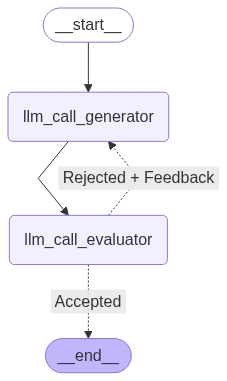

In [32]:
from typing_extensions import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END

model = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
)

# 用于结构化输出的模式，用于评估，定义反馈结构
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="判断笑话是否有趣。", # 评估等级：有趣或不好笑
    )
    feedback: str = Field(
        description="如果笑话不好笑，请提供有关如何改进它的反馈。", # 如果笑话不好笑，则提供关于如何改进它的反馈
    )

# 用于评估的增强型 LLM，配置为输出 Feedback 模式
evaluator = llm.with_structured_output(Feedback, method="function_calling")

# 评估器-优化器工作流的图状态定义
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

# 图中的节点
def llm_call_generator(state: State):
    """LLM 生成笑话，可能会结合之前评估的反馈"""
    if state.get("feedback"): # 检查状态中是否存在反馈，指示之前的评估
        msg = llm.invoke(
            f"写一个关于 {state['topic']} 的笑话，但要考虑反馈：{state['feedback']}" # 调用 LLM 生成笑话，结合反馈
        )
    else:
        msg = llm.invoke(f"写一个关于 {state['topic']} 的笑话") # 调用 LLM 生成初始笑话，不带反馈
    return {"joke": msg.content} # 返回生成的笑话，更新状态中的 'joke'

def llm_call_evaluator(state: State):
    """LLM 使用结构化输出评估生成的笑话"""
    grade = evaluator.invoke(f"评价笑话 {state['joke']}") # 调用评估器 LLM 来评价笑话
    return {"funny_or_not": grade.grade, "feedback": grade.feedback} # 返回评估等级和反馈，更新状态中的 'funny_or_not' 和 'feedback'

# 条件边缘函数，用于根据评估结果进行路由，创建反馈循环
def route_joke(state: State):
    """根据评估器的反馈，路由回笑话生成器或结束"""
    if state["funny_or_not"] == "funny": # 检查笑话是否被评估为有趣
        return "Accepted" # 如果笑话被接受，则路由到结束
    elif state["funny_or_not"] == "not funny": # 检查笑话是否被评估为不好笑
        return "Rejected + Feedback" # 如果笑话被拒绝，则路由回生成器以结合反馈

# 构建评估器-优化器工作流，使用 StateGraph
optimizer_builder = StateGraph(State)

# 将节点添加到图中
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# 定义边缘以连接节点并建立反馈循环
optimizer_builder.add_edge(START, "llm_call_generator") # 开始节点连接到笑话生成器
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator") # 生成器节点连接到评估器节点
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # 由 route_joke 返回的名称：要访问的下一个节点的名称
        "Accepted": END, # 如果笑话被接受，则路由到结束
        "Rejected + Feedback": "llm_call_generator", # 如果笑话被拒绝，则路由回生成器，创建反馈循环
    },
)

# 编译评估器-优化器工作流图
optimizer_workflow = optimizer_builder.compile()

from IPython.display import Image, display
try:
    display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [30]:
# 使用示例主题调用评估器-优化器工作流
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state["joke"]) 

当然！这里有一个关于猫的笑话：

---

有一天，一只猫走进了图书馆，走到前台对图书管理员说：

“你们有《老鼠的日记》这本书吗？”

图书管理员说：“没有。”

第二天，这只猫又来了，问：“你们有《老鼠的日记》吗？”

图书管理员说：“没有，我跟你说过了，我们没有这本书。”

第三天，猫又来了，问：“你们有《老鼠的日记》吗？”

图书管理员有点烦了，说：“我们没有！你都问了两天了！”

猫歪着头，轻轻地说：

“我只是想确认一下……你是不是变成老鼠了。”

---

😄 希望你喜欢这个笑话！需要更多关于猫的幽默吗？
